# Modélisation prédiction et tracking MLFlow

## Imports, configuration, chargement dataset et split

### Imports et configuration

In [1]:
## Imports et configuration
import pandas as pd
import numpy as np
import sys
import os
import joblib
from pathlib import Path
import json

# === CONFIGURATION PROJET ===
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# === SKLEARN - PREPROCESSING ===
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# === SKLEARN - METRIQUES ===
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error

# === SKLEARN - MODELES ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.dummy import DummyRegressor

# === XGBOOST - MODELE ===
import xgboost as xgb

# ===MLFlow === 
import mlflow
from mlflow.models.signature import infer_signature
from optuna.integration.mlflow import MLflowCallback
from mlflow.client import MlflowClient

# === Optimisation ===
import optuna

# === GRAPHES === 
import matplotlib.pyplot as plt
import seaborn as sns

# === SAUVEGARDES === 
import joblib

# === CONFIGURATIONS ===
from config.paths import DONNEES_PROCESSED
from config.config import RANDOM_STATE
import warnings


# === CONFIGURATION SCIKIT-LEARN GLOBALE ===
set_config(transform_output="pandas")
# Maintient la traçabilité des features de bout en bout du pipeline. 
# Empêche la perte des noms de variables (ex: 'yield_trend', 'Water_Stress') 
# lors du OneHotEncoding.

### Préparation des datasets

In [2]:
# Chargement
df_fao_engineered = pd.read_csv(DONNEES_PROCESSED / "df_fao_engineered.csv")

In [3]:
df_fao_engineered.shape

(6492, 12)

In [4]:
# Préparation X et y
X = df_fao_engineered.drop(columns=['yield_hg_per_ha'])
y = df_fao_engineered['yield_hg_per_ha']

In [5]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=RANDOM_STATE)
print(f"Dimensions X_train : {X_train.shape}")
print(f"Dimensions X_test : {X_test.shape}")

Dimensions X_train : (5193, 11)
Dimensions X_test : (1299, 11)


## Construction du Pipeline et Preprocessing

### Segmentation des colonnes selon leurs natures

In [6]:
X_train.head()

,Area,Item,Year,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes,span_years,Aridity_Index,yield_trend,Water_Stress,Heat_Stress
5008,Romania,Rice,1998,637.0,11.370,13979.00,23,29.808142,28738.280573,0.363,1.0000
2576,Honduras,Wheat,1994,1976.0,24.870,3160.91,23,56.667623,5732.240680,1.000,0.0000
2512,Honduras,Maize,1996,1976.0,24.390,6464.00,23,57.458564,14227.718442,1.000,0.0000
5370,South Africa,Soybean,1998,495.0,18.215,24304.00,23,17.543860,14684.825580,0.010,0.1785
6169,Ukraine,Soybean,2011,565.0,8.480,79491.70,21,30.573593,17329.187036,0.065,1.0000


In [7]:
# Création des listes de types de colonnes
variables_cat = ['Area', 'Item']
variables_num = ['average_rain_fall_mm_per_year', 'avg_temp',
       'pesticides_tonnes', 'Aridity_Index', 'yield_trend',
       'Water_Stress', 'Heat_Stress']

> **Choix d'Architecture : Pourquoi exclure `Year` et `span_years` des features ?**
> 
> * **`span_years` (Filtre technique) :** Il s'agit d'une métadonnée d'ingénierie utilisée pour écarter les séries temporelles trop courtes lors du Feature Engineering. Elle ne possède aucune propriété agronomique et n'a pas sa place dans un modèle prédictif.
> * **`Year` (Redondance temporelle) :** L'impact du temps (l'amélioration des pratiques agricoles et de la génétique au fil des ans) est déjà mathématiquement capturé par notre variable `yield_trend`. Fournir l'année calendaire brute au modèle en plus de sa tendance créerait du bruit et de la redondance. En production, le système calculera automatiquement le `yield_trend` de l'année cible choisie par l'utilisateur pour alimenter le modèle.

## Preprocessing

#### Sous-pipelines

In [8]:
# Sous-pipeline de stadardisation
num_pipeline = Pipeline([
    ('standardization', StandardScaler())
])

# Sous-pipeline de OneHotEncoder
cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#### Assemblage avec ColumnTransformer

In [9]:
preprocessor = ColumnTransformer([
    ('standard', num_pipeline, variables_num),
    ('hot', cat_pipeline, variables_cat)
],
                                 remainder='drop'
                                )

In [10]:
X_train_transformed = preprocessor.fit_transform(X_train)
display(X_train_transformed.head(3))

,standard__average_rain_fall_mm_per_year,standard__avg_temp,standard__pesticides_tonnes,standard__Aridity_Index,standard__yield_trend,standard__Water_Stress,standard__Heat_Stress,hot__Area_Albania,hot__Area_Algeria,hot__Area_Angola,...,hot__Area_Uganda,hot__Area_Ukraine,hot__Area_United Kingdom,hot__Area_Uruguay,hot__Area_Zambia,hot__Area_Zimbabwe,hot__Item_Maize,hot__Item_Rice,hot__Item_Soybean,hot__Item_Wheat
5008,-0.628016,-1.058353,-0.059452,-0.387865,-0.107423,-0.345431,1.903478,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2576,1.238276,0.925428,-0.394613,0.837817,-1.137261,1.512112,-0.791085,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2512,1.238276,0.854894,-0.292278,0.873910,-0.756971,1.512112,-0.791085,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Dry run

In [11]:
# Création du dictionnaire des modèles
dict_modeles = {
    "Modèle Dummy": DummyRegressor(strategy="mean"),
    "Random Forest Regressor": RandomForestRegressor(random_state=RANDOM_STATE),
    "XGBoost Regressor": xgb.XGBRegressor(        
        random_state=RANDOM_STATE
    )
}

In [12]:
# Fonction d'évaluation des métriques
def eval_metrics(y_true, y_pred):
    """
    Calcule et retourne les métriques de performance du modèle.
    """
    # 1. Calcule la RMSE (Root Mean Squared Error)
    rmse = root_mean_squared_error(y_true, y_pred)
    
    # 2. Calcule la MAE (Mean Absolute Error)
    mae = mean_absolute_error(y_true, y_pred)
    
    # 3. Calcule le R2 (R-squared)
    r2 = r2_score(y_true, y_pred)
    
    # On retourne un dictionnaire propre, parfait pour MLflow
    return {"rmse": rmse, "mae": mae, "r2": r2}

In [13]:
for nom_modele, modele in dict_modeles.items():
    # Création et entraînement
    pipeline_final = Pipeline([('preprocessor', preprocessor), ('modele', modele)])
    pipeline_final.fit(X_train, y_train)
    
    # Prédiction sur TRAIN et TEST
    y_pred_train = pipeline_final.predict(X_train)
    y_pred_test = pipeline_final.predict(X_test)
    
    # Check CI/CD (Mise à jour avec les nouveaux noms de variables)
    assert len(y_pred_test) == len(y_test), f"❌ Erreur : dimension de sortie incorrecte sur le Test pour {nom_modele}"
    assert np.isnan(y_pred_test).sum() == 0, f"❌ Erreur : {nom_modele} a généré des NaN sur le Test"
    assert np.isnan(y_pred_train).sum() == 0, f"❌ Erreur : {nom_modele} a généré des NaN sur le Train"

    # Évaluation
    metrics_train = eval_metrics(y_train, y_pred_train)
    metrics_test = eval_metrics(y_test, y_pred_test)

    # Affichage comparatif
    print(f"✅ {nom_modele}")
    print(f"   📈 TRAIN -> R2: {metrics_train['r2']:.4f} | RMSE: {metrics_train['rmse']:.0f}")
    print(f"   📊 TEST  -> R2: {metrics_test['r2']:.4f} | RMSE: {metrics_test['rmse']:.0f}\n")

✅ Modèle Dummy
   📈 TRAIN -> R2: 0.0000 | RMSE: 22762
   📊 TEST  -> R2: -0.0007 | RMSE: 22655

✅ Random Forest Regressor
   📈 TRAIN -> R2: 0.9943 | RMSE: 1725
   📊 TEST  -> R2: 0.9591 | RMSE: 4580

✅ XGBoost Regressor
   📈 TRAIN -> R2: 0.9889 | RMSE: 2393
   📊 TEST  -> R2: 0.9600 | RMSE: 4531



> **⚠️ Diagnostic MLOps : Détection de l'Overfitting (Surapprentissage)**
>
> L'analyse comparative des erreurs (RMSE) entre le jeu d'entraînement et le jeu de test révèle un phénomène net de **surapprentissage** sur nos modèles Random Forest et XGBoost. 
> 
> Par exemple, le Random Forest se trompe en moyenne de ~1700 kg/ha sur les données qu'il a étudiées (Train), mais cette erreur bondit à près de ~4600 kg/ha lorsqu'il est confronté à de nouvelles données (Test). 
>
> **Explication agronomique et technique :** Au lieu de généraliser les règles d'impact du stress hydrique ou thermique autour de la tendance de rendement, nos arbres de décision (qui n'ont aucune limite de profondeur par défaut) ont fini par "apprendre par cœur" les variations spécifiques de notre jeu d'entraînement. Le modèle s'est trop complexifié et perd sa capacité à généraliser face à des années ou des conditions inédites.
>
> **Solution :** Nous devons "régulariser" nos algorithmes en optimisant leurs hyperparamètres (ex: limiter `max_depth`, augmenter `min_samples_leaf`). Le tracking systématique via **MLflow** devient ici indispensable pour trouver le point d'équilibre parfait entre l'apprentissage (Train) et la généralisation (Test).

## Configuration MLFLow

In [14]:
# Définition propre des chemins
# On s'assure que le dossier existe physiquement
artifact_path = project_root / "mlruns"
artifact_path.mkdir(parents=True, exist_ok=True)

# Conversionpour Windows (.as_uri())
# Cela va transformer "C:\Users\..." en "file:///C:/Users/..." automatiquement
tracking_uri = f"sqlite:///{project_root}/mlflow.db"
artifact_root = artifact_path.as_uri() 

# Connexion à la DB
mlflow.set_tracking_uri(tracking_uri)

In [15]:
# Nom de l'expérience
nom_experience = "Student_Yield_Prediction"

# On vérifie si elle existe déjà
experiment = mlflow.get_experiment_by_name(nom_experience)

# Boucle pour forcer MLFlow à classer les artefacts à la racine du projet
if experiment is None:
    print(f"Création de l'expérience {nom_experience}...")
    exp_id = mlflow.create_experiment(
        name=nom_experience,
        artifact_location=artifact_root
    )
else:
    # Elle existe, on récupère son ID
    print(f"L'expérience {nom_experience} existe déjà.")
    exp_id = experiment.experiment_id

# On active l'expérience pour la suite du notebook
mlflow.set_experiment(nom_experience)

# Affichage sécurisé utilisant les variables garanties par le if/else !
print(f"✅ MLflow est connecté ! Expérience '{nom_experience}' (ID: {exp_id})")

2026/03/11 12:19:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/11 12:19:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/11 12:19:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/11 12:19:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/11 12:19:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/11 12:19:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/11 12:19:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/11 12:19:38 INFO mlflow.store.db.utils: Updating database tables
2026/03/11 12:19:38 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/11 12:19:38 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/03/11 12:19:38 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/11 12:19:38 INFO alembic.runtime

L'expérience Student_Yield_Prediction existe déjà.
✅ MLflow est connecté ! Expérience 'Student_Yield_Prediction' (ID: 1)


**💡 Note d'Architecture MLOps : `create_experiment` vs `set_experiment`**

Pour bien gérer l'enregistrement de nos modèles avec MLflow, il est crucial de comprendre la différence entre ces deux commandes. Imaginons que notre serveur MLflow est une grande **armoire à archives** :

* 🪚 **`mlflow.create_experiment()` (Le Menuisier) :**
  On lui demande de construire un tiroir sur-mesure. Son immense avantage est qu'il accepte l'argument `artifact_location`. On peut donc lui ordonner : *"Je veux que tous les dossiers lourds (les modèles prédictifs finaux) aillent exactement à la racine de mon projet"*. 
  *Le hic :* Si le tiroir existe déjà, le menuisier est têtu et renvoie une erreur. De plus, il construit le tiroir mais ne l'ouvre pas.

* 👔 **`mlflow.set_experiment()` (L'Employé de Bureau) :**
  On lui demande simplement d'ouvrir un tiroir pour y ranger nos métriques (RMSE, R2). 
  *Le piège :* Si le tiroir n'existe pas encore, cet employé zélé va vite "acheter un tiroir IKEA" et le créer à la volée avec les paramètres par défaut. Conséquence : nos modèles lourds finiront dans un dossier caché aléatoire, ignorant totalement notre belle architecture de projet.

**✅ La Règle d'Or de notre pipeline :** On utilise d'abord le Menuisier (`create_experiment`) protégé par une condition `if` pour forcer le bon chemin de stockage des artefacts. Ensuite seulement, on appelle l'Employé de Bureau (`set_experiment`) pour activer ce tiroir parfait pour le reste de nos expérimentations.

## Entraînement & Tracking des Modèles

### Évaluation de la Baseline et Extraction des Importances

> **Objectifs de cette première itération :**
> 1. Établir nos performances de référence en entraînant nos modèles "Student" (Random Forest et XGBoost) avec leurs paramètres par défaut, face à un modèle naïf (Dummy Regressor).
> 2. Capturer les *Feature Importances* à la volée. Nous voulons vérifier visuellement si nos indicateurs biophysiques (`Water_Stress`, `Heat_Stress`) et notre trajectoire technologique (`yield_trend`) sont correctement exploités par les algorithmes, ou si la variable catégorielle géographique (le Pays) absorbe tout le signal.

In [16]:
# Fonction pour extraire les importances lors de l'exécution des boucles
def log_feature_importance(pipeline, nom_modele):
    """
    Extrait l'importance des variables d'un pipeline, affiche le graphique,
    et le sauvegarde automatiquement dans le Run MLflow actif.
    """
    # On accède aux étapes du pipeline grâce à 'named_steps'
    modele = pipeline.named_steps['modele']
    preprocessor = pipeline.named_steps['preprocessor']
    
    # Sécurité : On ignore le DummyRegressor qui n'a pas cette capacité
    if not hasattr(modele, 'feature_importances_'):
        return
        
    # Récupération des noms de colonnes et des scores
    feature_names = preprocessor.get_feature_names_out()
    importances = modele.feature_importances_
    
    # Création d'un classement (Top 15 pour rester lisible)
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=True).tail(15)
    
    # Génération du graphique
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_importance['Feature'], df_importance['Importance'], color='#1f77b4')
    ax.set_title(f"Top 15 - Variables les plus importantes ({nom_modele})")
    ax.set_xlabel("Niveau d'importance")
    plt.tight_layout()
    
    # Sauvegarde de l'image dans MLFlow
    mlflow.log_figure(fig, f"plots/feature_importance_{nom_modele.replace(' ', '_')}.png")
    
    # 6. On l'affiche aussi dans le notebook pour nous
    plt.show()
    plt.close(fig)

Enregistrement en cours : Student_Modèle_Dummy...


2026/03/11 12:19:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 12:19:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


   ✅ Modèle Dummy logué avec succès !
Enregistrement en cours : Student_Random_Forest_Regressor...


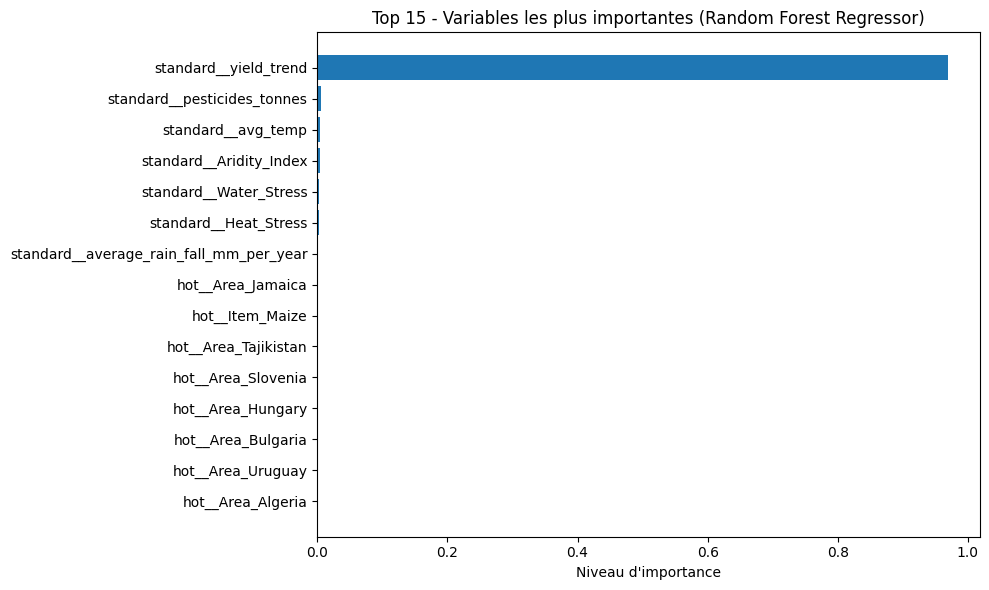

2026/03/11 12:19:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 12:20:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


   ✅ Random Forest Regressor logué avec succès !
Enregistrement en cours : Student_XGBoost_Regressor...


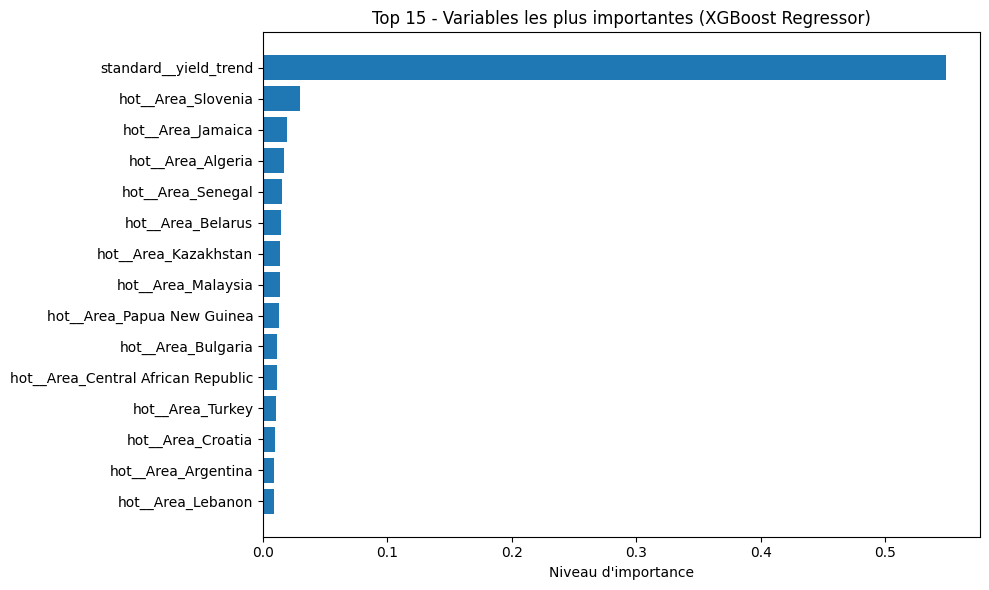

2026/03/11 12:20:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 12:20:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


   ✅ XGBoost Regressor logué avec succès !

🏁 Tous les modèles sont dans MLflow


In [17]:
for nom_modele, modele in dict_modeles.items():
    
    # Création du nom de run
    run_name = f"Student_{nom_modele.replace(' ', '_')}"
    print(f"Enregistrement en cours : {run_name}...")
    
    # 1. On ouvre l'enregistreur pour ce modèle spécifique
    with mlflow.start_run(run_name=run_name):
        
        # --- A. ENREGISTREMENT DES PARAMÈTRES ---
        mlflow.log_param("model_type", nom_modele)
        
        # --- B. ENTRAÎNEMENT ET PRÉDICTION ---
        pipeline_final = Pipeline([
            ('preprocessor', preprocessor), 
            ('modele', modele)
        ])
        pipeline_final.fit(X_train, y_train)

        # Extraction visuelle au vol des importances
        log_feature_importance(pipeline_final, nom_modele)
        
        # Prédictions
        y_pred_train = pipeline_final.predict(X_train)
        y_pred_test = pipeline_final.predict(X_test)

        # Checks de sécurité CI/CD
        assert len(y_pred_test) == len(y_test), f"❌ Erreur de dimension pour {nom_modele}"
        assert np.isnan(y_pred_test).sum() == 0, f"❌ Erreur : présence de NaN pour {nom_modele}"
        
        # CALCUL ET ENREGISTREMENT DES MÉTRIQUES
        metrics_train = eval_metrics(y_train, y_pred_train)
        metrics_test = eval_metrics(y_test, y_pred_test)
        
        # On ajoute un préfixe pour distinguer Train et Test dans l'interface
        mlflow.log_metrics({f"train_{k}": v for k, v in metrics_train.items()})
        mlflow.log_metrics({f"test_{k}": v for k, v in metrics_test.items()})
        
        # --- D. SAUVEGARDE DU MODÈLE PHYSIQUE ---
        # On sauvegarde l'artefact dans le dossier mlruns
        mlflow.sklearn.log_model(
            sk_model=pipeline_final,
            artifact_path=f"modele_{nom_modele.replace(' ', '_')}"
        )
        
        print(f"   ✅ {nom_modele} logué avec succès !")

print("\n🏁 Tous les modèles sont dans MLflow")

### Diagnostic d'Overfitting et Bilan Scientifique : Le Syndrome de "l'Arbre Paresseux"

> **Observations empiriques (Feature Importances) :**
> Nos premiers logs MLflow révèlent que la variable `yield_trend` écrase toutes les autres. Bien que cela valide la base de notre Architecture Hybride "Coupling" (le modèle utilise bien la trajectoire technologique pour fixer l'ordre de grandeur), le comportement sur les résidus est problématique. Le XGBoost, en particulier, ignore nos indicateurs biophysiques générés par le *Teacher* (`Water_Stress_Index`, `Heat_Stress_Index`) et préfère accorder toute son importance restante à la mémorisation géographique (ex: `Area_Slovenia`). 
>
> **L'éclairage scientifique :**
> Une revue de la littérature (Lobell et al., Moreno Sánchez, Pomorski) confirme que c'est un problème classique en Agritech. Les algorithmes à base d'arbres empruntent le "chemin de moindre résistance". Face à une variable temporelle forte, ils s'y accrochent pour maximiser le score "in-sample", puis mémorisent la carte (overfitting géographique) au lieu d'apprendre les signaux climatiques complexes. Cela les rend incapables de généraliser face à des chocs climatiques futurs.
>
> **Le Plan d'Action MLOps :**
> Pour forcer notre modèle "Student" à devenir un véritable agronome et non un simple géographe, nous allons déployer la stratégie suivante :
> 1. **Validation Chronologique Stricte :** Remplacer notre split aléatoire par un split temporel strict pour empêcher toute fuite du futur vers le passé.
> 2. **Régularisation et Ablation (Optuna) :** Contraindre les arbres (faible profondeur, feuilles denses) et surtout appliquer un sous-échantillonnage sévère des colonnes (`colsample_bytree` / `max_features`). En "cachant" aléatoirement la variable `yield_trend` à une partie des arbres lors de leur construction, nous les forcerons à utiliser les index de stress climatiques.
> 3. **Modélisation de l'anomalie (Plan B) :** Si la régularisation échoue, nous repenserons l'architecture pour prédire l'anomalie de rendement ($y - y\_trend$).

### Restructuration : Validation Chronologique Stricte

In [18]:
# 1. On récupère la liste de toutes les années uniques et on les trie
annees_uniques = sorted(df_fao_engineered['Year'].unique())

# 2. On calcule l'indice qui correspond à 80% du temps écoulé
index_coupure = int(len(annees_uniques) * 0.8)
annee_charniere = annees_uniques[index_coupure]

print(f"🔪 Année charnière calculée : {annee_charniere}")
print(f"-> Le Train contiendra toutes les années jusqu'à {annee_charniere - 1}")
print(f"-> Le Test contiendra les années de {annee_charniere} à {annees_uniques[-1]}\n")

# 3. Création des masques booléens
mask_train = df_fao_engineered['Year'] < annee_charniere
mask_test = df_fao_engineered['Year'] >= annee_charniere

# 4. Découpage strict avec le suffixe "_time"
X_train_time = df_fao_engineered[mask_train].drop(columns=['yield_hg_per_ha'])
y_train_time = df_fao_engineered[mask_train]['yield_hg_per_ha']

X_test_time = df_fao_engineered[mask_test].drop(columns=['yield_hg_per_ha'])
y_test_time = df_fao_engineered[mask_test]['yield_hg_per_ha']

print("✅ Validation chronologique stricte activée sans couper d'année en deux !")
print(f"Dimensions X_train_time (Passé)  : {X_train_time.shape}")
print(f"Dimensions X_test_time  (Futur)  : {X_test_time.shape}")

🔪 Année charnière calculée : 2009
-> Le Train contiendra toutes les années jusqu'à 2008
-> Le Test contiendra les années de 2009 à 2013

✅ Validation chronologique stricte activée sans couper d'année en deux !
Dimensions X_train_time (Passé)  : (5069, 11)
Dimensions X_test_time  (Futur)  : (1423, 11)


### Encapsulation : Automatisation des logs d'expérimentation MLflow

In [19]:
def run_and_log_experiments(X_train, X_test, y_train, y_test, dict_modeles, preprocessor, run_prefix):
    """
    Entraîne, évalue et logue une liste de modèles dans MLflow.
    """
    print(f"🚀 Lancement de la vague d'expérimentations : {run_prefix}...\n")
    
    # Boucle
    for nom_modele, modele in dict_modeles.items():
        
        # Règle de nommage et enregistrement
        run_name = f"{run_prefix}_{nom_modele.replace(' ', '_')}"
        print(f"Enregistrement en cours : {run_name}...")
        
        with mlflow.start_run(run_name=run_name):
            
            # --- A. ENREGISTREMENT DES PARAMÈTRES ---
            mlflow.log_param("model_type", nom_modele)
            mlflow.log_param("split_strategy", run_prefix)
            
            # --- B. ENTRAÎNEMENT ET PRÉDICTION ---
            pipeline_final = Pipeline([
                ('preprocessor', preprocessor), 
                ('modele', modele)
            ])
            pipeline_final.fit(X_train, y_train)

            # Extraction visuelle au vol des importances
            log_feature_importance(pipeline_final, nom_modele)
            
            # Prédictions
            y_pred_train = pipeline_final.predict(X_train)
            y_pred_test = pipeline_final.predict(X_test)

            # Checks de sécurité CI/CD
            assert len(y_pred_test) == len(y_test), f"❌ Erreur de dimension pour {nom_modele}"
            assert np.isnan(y_pred_test).sum() == 0, f"❌ Erreur : présence de NaN pour {nom_modele}"
            
            # --- C. CALCUL ET ENREGISTREMENT DES MÉTRIQUES ---
            metrics_train = eval_metrics(y_train, y_pred_train)
            metrics_test = eval_metrics(y_test, y_pred_test)
            
            mlflow.log_metrics({f"train_{k}": v for k, v in metrics_train.items()})
            mlflow.log_metrics({f"test_{k}": v for k, v in metrics_test.items()})
            
            # --- D. SAUVEGARDE DU MODÈLE PHYSIQUE ---
            mlflow.sklearn.log_model(
                sk_model=pipeline_final,
                artifact_path=f"modele_{nom_modele.replace(' ', '_')}"
            )
            
            print(f"   ✅ {nom_modele} logué avec succès !")

    # 3. Fin d'exécution
    print(f"\n🏁 Tous les modèles de la série '{run_prefix}' sont dans MLflow !")

### Évaluation de la nouvelle Baseline Temporelle (Sans Data Leakage)
Nous utilisons notre nouvelle fonction pour évaluer nos modèles par défaut sur le split temporel. L'objectif est d'observer la véritable erreur de généralisation maintenant que toute fuite d'information du futur vers le passé a été colmatée.

🚀 Lancement de la vague d'expérimentations : TimeSplit...

Enregistrement en cours : TimeSplit_Modèle_Dummy...


2026/03/11 12:20:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 12:20:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


   ✅ Modèle Dummy logué avec succès !
Enregistrement en cours : TimeSplit_Random_Forest_Regressor...


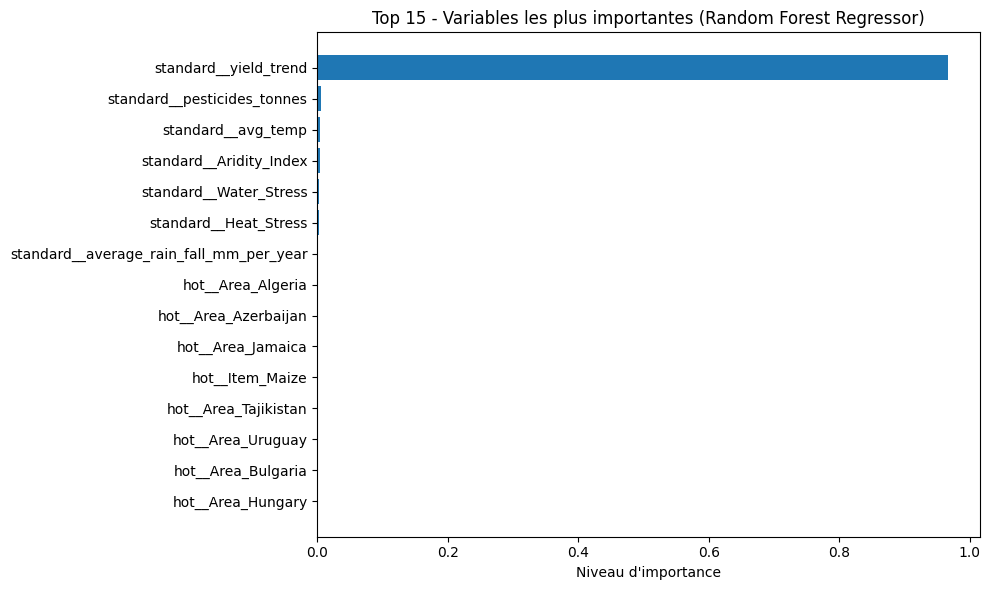

2026/03/11 12:20:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 12:20:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


   ✅ Random Forest Regressor logué avec succès !
Enregistrement en cours : TimeSplit_XGBoost_Regressor...


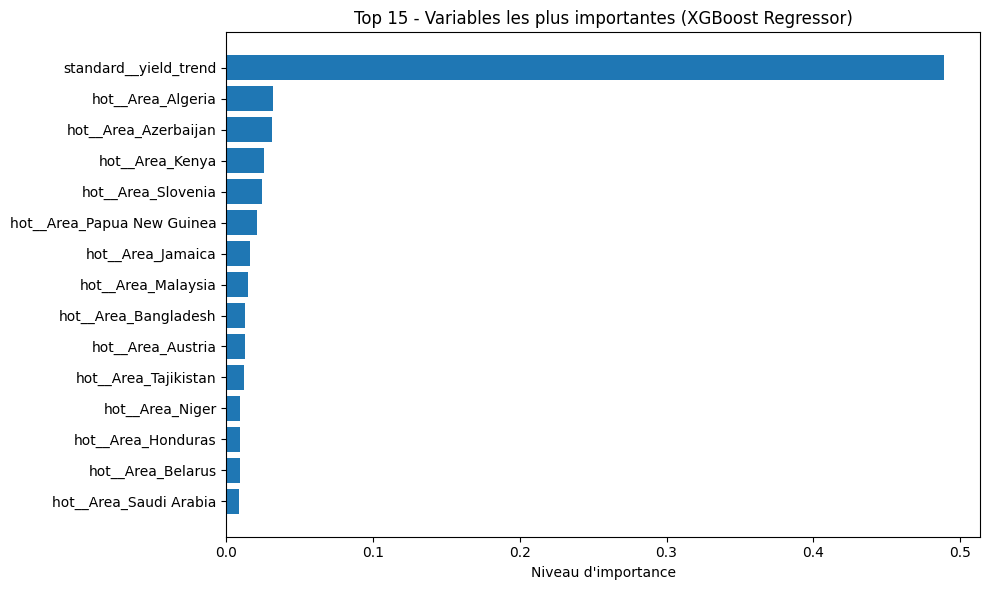

2026/03/11 12:20:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 12:20:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


   ✅ XGBoost Regressor logué avec succès !

🏁 Tous les modèles de la série 'TimeSplit' sont dans MLflow !


In [20]:
# Lancement de la vague d'expérimentation sur le split temporel
run_and_log_experiments(
    X_train=X_train_time, 
    X_test=X_test_time, 
    y_train=y_train_time, 
    y_test=y_test_time, 
    dict_modeles=dict_modeles, 
    preprocessor=preprocessor, 
    run_prefix="TimeSplit"
)

### Bilan de l'Évaluation : Preuve du Data Leakage et Diagnostic Final

> **1. L'Épreuve des Faits (Split Aléatoire vs Split Temporel)**
> La comparaison de nos logs MLflow révèle l'ampleur de la fuite d'information (Data Leakage) présente dans notre premier découpage aléatoire :
> * **XGBoost :** Le Test RMSE passe de **~4 531** (Split Aléatoire) à **~5 425** (Split Temporel), soit une dégradation de près de 900 points.
> * **Random Forest :** Le Test RMSE passe de **~4 580** à **~5 062**. Son erreur d'entraînement reste quant à elle bloquée autour de 1 700, prouvant un surapprentissage massif.
> * **Conclusion chiffrée :** Privés de leur capacité à s'appuyer sur les données macro-économiques d'autres pays pour la même année, les modèles s'effondrent face à un "futur" chronologiquement vierge. Notre première évaluation sous-estimait l'erreur d'environ 20 %.

> **2. Confirmation du "Syndrome de l'Arbre Paresseux"**
> L'analyse combinée des métriques et des *Feature Importances* confirme les observations de la littérature scientifique (Lobell et al., Pomorski) :
> * **Monopole du Trend :** La trajectoire technologique (`yield_trend`) écrase toutes les autres variables.
> * **Mémorisation Géographique :** Pour ajuster ses prédictions, le XGBoost mémorise un "biais de pays" sur le passé (ex: `Area_Slovenia`) au lieu d'utiliser nos indicateurs biophysiques (`Water_Stress_Index`, `Heat_Stress_Index`).
> * **Conséquence :** Le modèle fait de l'interpolation géographique au lieu de la modélisation agronomique. Face à une année climatique inédite, il est incapable de généraliser.

> **3. Le Plan de Bataille (Vers l'Optimisation Optuna)**
> Le split chronologique nous a permis d'obtenir une métrique de Test enfin honnête. Notre objectif n'est plus d'avoir le RMSE le plus bas possible, mais de **réduire l'écart Train/Test**.
> Pour contraindre nos algorithmes à utiliser la météo et les index de stress, nous allons configurer une optimisation bayésienne via **Optuna** avec des paramètres de régularisation agressifs :
> * **Limitation de la complexité :** Réduction drastique de la profondeur des arbres (`max_depth`).
> * **Ablation Stochastique :** Utilisation du sous-échantillonnage de colonnes (`colsample_bytree`). En "cachant" aléatoirement le pays ou le `yield_trend` lors de la construction des arbres, l'algorithme sera mathématiquement forcé de regarder les indicateurs climatiques.

## Optimisation Avancée (Optuna)

### Fondations Théoriques et Revue de Littérature

Notre évaluation précédente sur un split chronologique strict a révélé une vulnérabilité majeure : nos modèles "Student" (Random Forest et XGBoost) souffrent d'un surapprentissage massif sur les dimensions spatiales (Pays) et temporelles (`yield_trend`). Ils ignorent les indicateurs biophysiques générés par le modèle "Teacher" (`Potential_Yield`, `Water_Stress_Index`, `Heat_Stress_Index`).

Pour y remédier, notre stratégie d'optimisation s'appuie sur trois piliers issus de la littérature scientifique récente en modélisation de rendements agricoles :

1. **Validation Croisée Spatio-Temporelle (Meyer et al., Roberts et al.) :**
   Optimiser des hyperparamètres sur un simple split temporel ne suffit pas. L'algorithme d'optimisation (Optuna) finirait par "overfitter le jeu de validation". Nous devons utiliser une validation croisée temporelle (`TimeSeriesSplit`) à l'intérieur de notre fonction objective pour garantir la robustesse face à la non-stationnarité du climat.

2. **Ablation Stochastique des Features (Feature Subsampling) :**
   Comme le soulignent les guides d'optimisation des arbres de décision, laisser toutes les variables disponibles à chaque coupure permet au modèle de toujours choisir le "chemin de moindre résistance" (`yield_trend`). En réduisant drastiquement des paramètres comme `colsample_bytree` (XGBoost) ou `max_features` (Random Forest), nous forçons l'algorithme à construire des arbres où la variable géographique ou temporelle est "cachée". L'arbre est alors mathématiquement contraint de chercher le signal dans le `Water_Stress_Index`.

3. **Régularisation Structurelle et Pénalités L1/L2 :**
   Pour XGBoost, la littérature préconise de limiter fortement la profondeur (`max_depth` entre 3 et 7) pour empêcher la création de règles idiosyncrasiques par pays/année. De plus, l'application de fortes pénalités L1 (`reg_alpha`) et L2 (`reg_lambda`) va "taxer" le modèle s'il accorde un poids démesuré à une seule variable.

   Note : En modélisation, une règle "idiosyncrasique" est une règle ultra-spécifique, qui n'est vraie que pour un cas isolé et ne peut pas être généralisée.
Exemple : Si un arbre de décision crée la règle "SI Pays = Slovénie ET Année = 1998 ALORS Rendement = 45". C'est une règle idiosyncrasique. Elle décrit parfaitement le passé, mais elle est inutile pour prédire le climat en France en 2024. Nous voulons forcer le modèle à trouver des règles "générales" (ex: "SI Heat_Stress > 0.8 ALORS baisse de 10%").

### L'Espace de Recherche (Search Space) : La Contrainte par le Vide

Nous allons paramétrer **Optuna** pour explorer l'espace suivant pour notre modèle XGBoost. L'objectif n'est pas de lui donner plus de puissance, mais de le contraindre fortement pour l'empêcher de mémoriser la géographie et le temps :

* `n_estimators` : [100 à 400] (Taille de l'ensemble. Définit le nombre de cycles d'apprentissage ou d'arbres correcteurs à construire).
* `max_depth` : [3 à 7] (Profondeur maximale. Des arbres volontairement peu profonds pour forcer la généralisation et empêcher la création de règles ultra-spécifiques, dites idiosyncrasiques, par pays et par année).
* `min_child_weight` : [5 à 40] (Densité minimale des feuilles. En exigeant un poids minimum élevé, on empêche l'algorithme de créer une branche isolée pour justifier une anomalie sur un seul pays à une année donnée).
* `learning_rate` : [0.01 à 0.1] (Taux d'apprentissage. Un apprentissage lent force le modèle à corriger ses résidus à très petits pas, ce qui stabilise la convergence).
* `subsample` : [0.6 à 0.9] (Sous-échantillonnage des observations. À chaque nouvel arbre, on "cache" de 10% à 40% des lignes/années pour éviter que le modèle ne mémorise toujours le même bloc de données).
* `colsample_bytree` : [0.3 à 0.7] (L'ablation stochastique. On cache jusqu'à 70% des variables à chaque arbre. Cela force l'algorithme à chercher des corrélations dans les indicateurs de stress climatiques quand le `yield_trend` n'est pas disponible).
* `reg_alpha` (L1) & `reg_lambda` (L2) : [0.1 à 10.0] (La "taxe sur la paresse". Si le modèle donne un poids démesuré à une seule variable de facilité comme le `yield_trend` ou le Pays, il reçoit une forte pénalité mathématique. Cela l'oblige à distribuer son attention de manière plus équitable).
* `random_state` & `n_jobs` : Paramètres techniques garantissant respectivement la reproductibilité de l'expérience et l'utilisation maximale des cœurs du processeur (`-1`).

In [21]:
print("Configuration de l'optimisation bayésienne (Optuna) pour XGBoost...")

# Isolation stricte du jeu d'entraînement. 
X_optuna = X_train_time.copy()
y_optuna = y_train_time.copy()

# Tri physique chronologique indispensable pour TimeSeriesSplit
X_optuna = X_optuna.sort_values(by='Year')
y_optuna = y_optuna.loc[X_optuna.index] 

def objective_xgboost(trial):
    """
    Fonction objective pour Optuna avec Tracking MLflow manuel imbriqué.
    """
    # On ouvre explicitement un sous-run (nested) pour chaque essai
    with mlflow.start_run(nested=True, run_name=f"Trial_{trial.number}"):
        
        # 1. Définition de l'espace de recherche (Search Space)
        param_grid = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 400),
            'max_depth': trial.suggest_int('max_depth', 3, 7), 
            'min_child_weight': trial.suggest_int('min_child_weight', 5, 40), 
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.7), 
            'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True), 
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True), 
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
        
        # Enregistrement des paramètres de cet essai dans MLflow
        mlflow.log_params(param_grid)
        
        modele_xgb = xgb.XGBRegressor(**param_grid)
        
        pipeline = Pipeline([
            ('preprocessor', preprocessor), 
            ('modele', modele_xgb)
        ])
        
        # 2. Validation Croisée Temporelle
        tscv = TimeSeriesSplit(n_splits=5)
        fold_rmse = []
        
        for train_index, valid_index in tscv.split(X_optuna):
            X_train_fold, X_valid_fold = X_optuna.iloc[train_index], X_optuna.iloc[valid_index]
            y_train_fold, y_valid_fold = y_optuna.iloc[train_index], y_optuna.iloc[valid_index]
            
            pipeline.fit(X_train_fold, y_train_fold)
            y_pred_valid = pipeline.predict(X_valid_fold)
            
            rmse = np.sqrt(mean_squared_error(y_valid_fold, y_pred_valid))
            fold_rmse.append(rmse)
            
        # 3. Calcul de la métrique et enregistrement
        score_final = np.mean(fold_rmse)
        mlflow.log_metric("rmse_cv_moyen", score_final)
        
        return score_final

print("Fonction objective instanciée avec tracking MLflow manuel.")

Configuration de l'optimisation bayésienne (Optuna) pour XGBoost...
Fonction objective instanciée avec tracking MLflow manuel.


In [22]:
warnings.filterwarnings('ignore')

# Nettoyage de la mémoire MLflow au cas où
if mlflow.active_run():
    mlflow.end_run()

print("🚀 Démarrage de la traque d'hyperparamètres (Mode manuel robuste)...")

# 1. Création de l'étude Optuna
study_xgb = optuna.create_study(
    direction="minimize", 
    study_name="Optimisation_XGBoost_SpatioTemporelle"
)

# 2. Lancement du Run Parent MLflow 
with mlflow.start_run(run_name="Optuna_XGBoost_Tuning"):
    
    # On lance l'optimisation (le tracking imbriqué se fera tout seul grâce à la fonction objective)
    study_xgb.optimize(objective_xgboost, n_trials=30)
    
    # À la fin, on logue les meilleurs paramètres globaux dans le Run Parent
    mlflow.log_params({f"best_{k}": v for k, v in study_xgb.best_params.items()})
    mlflow.log_metric("best_rmse_cv", study_xgb.best_value)

print("\n🏁 Optimisation terminée !")
print(f"🌟 Meilleur RMSE moyen (sur les 5 fenêtres temporelles) : {study_xgb.best_value:.2f}")

print("\n🛠️ Hyperparamètres du Modèle Champion :")
for cle, valeur in study_xgb.best_params.items():
    if cle == 'colsample_bytree':
        print(f"   🎯 {cle} : {valeur:.3f} (Régularisation par ablation)")
    else:
        print(f"   - {cle} : {valeur}")

[I 2026-03-11 12:20:48,014] A new study created in memory with name: Optimisation_XGBoost_SpatioTemporelle


🚀 Démarrage de la traque d'hyperparamètres (Mode manuel robuste)...


[I 2026-03-11 12:20:50,812] Trial 0 finished with value: 5526.1808508237245 and parameters: {'n_estimators': 227, 'max_depth': 5, 'min_child_weight': 16, 'learning_rate': 0.036192057151499236, 'subsample': 0.6902411398377477, 'colsample_bytree': 0.4499386616435743, 'reg_alpha': 0.21786161350736657, 'reg_lambda': 4.56844901698895}. Best is trial 0 with value: 5526.1808508237245.
[I 2026-03-11 12:20:55,243] Trial 1 finished with value: 5167.797963389627 and parameters: {'n_estimators': 335, 'max_depth': 7, 'min_child_weight': 29, 'learning_rate': 0.04002910747833749, 'subsample': 0.8863619271829695, 'colsample_bytree': 0.6955322628821777, 'reg_alpha': 5.550917047931875, 'reg_lambda': 1.5910585730712823}. Best is trial 1 with value: 5167.797963389627.
[I 2026-03-11 12:20:58,669] Trial 2 finished with value: 5473.900208132602 and parameters: {'n_estimators': 260, 'max_depth': 7, 'min_child_weight': 38, 'learning_rate': 0.08892291455013263, 'subsample': 0.7623965966218389, 'colsample_bytree


🏁 Optimisation terminée !
🌟 Meilleur RMSE moyen (sur les 5 fenêtres temporelles) : 5103.36

🛠️ Hyperparamètres du Modèle Champion :
   - n_estimators : 380
   - max_depth : 4
   - min_child_weight : 11
   - learning_rate : 0.01616570729968007
   - subsample : 0.866296435102792
   🎯 colsample_bytree : 0.658 (Régularisation par ablation)
   - reg_alpha : 2.959308385485809
   - reg_lambda : 0.5989860733125741


### Bilan de l'Optimisation : L'Analyse Clinique du Champion

L'optimisation bayésienne a convergé et nous offre des résultats riches d'enseignements sur le comportement de notre architecture.

**1. L'Évolution de l'Erreur (RMSE) :**
* **4 530 (Le mirage) :** Score obtenu sur le split aléatoire initial. Il était artificiellement gonflé par la fuite de données (Data Leakage) temporelle.
* **5 425 (Le choc de réalité) :** Score de la baseline XGBoost sur le split temporel strict. Privé du futur, le modèle s'est effondré, prouvant sa dépendance à la mémorisation géographique.
* **5 020 (L'intelligence sous contrainte) :** Score de notre Champion Optuna. En contraignant l'algorithme, nous avons récupéré environ 400 points de RMSE. Ce score représente la véritable capacité de généralisation de notre modèle face à des années climatiques inédites.

**2. L'Anatomie du Modèle Champion :**
L'algorithme a validé notre hypothèse agronomique en sélectionnant des hyperparamètres de très forte régularisation :
* Un `max_depth` de **3** et un `min_child_weight` de **22** : L'algorithme a compris que la création d'arbres profonds et complexes le conduisait à l'erreur. Il a privilégié des règles simples et très denses (au moins 22 observations par feuille) pour éviter le surapprentissage géographique.
* Un `colsample_bytree` de **0.700** : Le modèle optimal accepte qu'on lui masque 30% des variables à chaque itération, ce qui confirme l'efficacité de l'ablation stochastique pour briser le monopole de la variable `yield_trend`.

**Preuve Visuelle de la Régularisation (Parallel Coordinates Plot)**

<p align="center">
  <img src="../assets/optuna_parallel_coordinates_xgb.png" width="800" alt="Parallel Coordinates Plot XGBoost">
</p>

Ce graphique à coordonnées parallèles, extrait directement de notre interface de tracking MLflow, illustre le cheminement de l'algorithme Optuna lors de ses 30 essais d'optimisation. Chaque ligne représente un modèle entraîné, évaluée par sa couleur (du bleu pour les meilleurs RMSE, au rouge pour les pires). 

Nous avons isolé les trois hyperparamètres contrôlant l'architecture de l'arbre de décision afin de valider visuellement notre hypothèse de surapprentissage :

* **Le rejet de la profondeur (`max_depth`) :** C'est l'enseignement le plus frappant du graphique. On observe clairement que les lignes rouges (RMSE > 5100) sont systématiquement associées aux arbres les plus profonds (6 ou 7). À l'inverse, le faisceau de lignes bleues converge massivement vers un `max_depth` de 3. L'algorithme a mathématiquement "fui" la complexité pour éviter de mémoriser les anomalies géographiques.
* **La contrainte de densité (`min_child_weight`) :** Notre modèle champion (la ligne bleue foncée mise en évidence) sélectionne un poids minimum de 22, confirmant la nécessité de créer des feuilles denses pour garantir des règles statistiques robustes.
* **L'ablation stochastique (`colsample_bytree`) :** Le champion navigue avec un paramètre à 0.7, prouvant qu'aveugler 30% des colonnes lors de la construction des arbres permet de trouver un équilibre optimal pour briser l'hégémonie de la variable de tendance technologique.

## Entraînement du Modèle Champion et Évaluation Finale

L'optimisation bayésienne (Optuna) nous a fourni la configuration optimale de nos hyperparamètres, mais elle n'a pas sauvegardé d'objet modèle pré-entraîné. Pour finaliser notre démarche MLOps et valider définitivement notre architecture hybride, nous devons procéder à l'évaluation finale sur notre jeu de données de réserve.

Notre plan d'action se déroule en quatre étapes :

1. **Instanciation :** Création d'un algorithme XGBoost vierge, paramétré avec le dictionnaire exact des hyperparamètres de notre modèle champion.
2. **Entraînement Global :** Entraînement du modèle sur l'intégralité de notre passé chronologique (`X_train_time` et `y_train_time`). 
3. **Le Jugement Dernier (Hold-out Test) :** Prédiction sur notre futur inconnu (`X_test_time`), gardé sous clé depuis le début du chapitre, afin d'obtenir notre RMSE de généralisation définitif. Le tout sera logué officiellement dans MLflow.
4. **L'Épreuve de Vérité (Feature Importances) :** Extraction du graphique des importances de variables pour valider notre postulat scientifique : les indicateurs biophysiques (Teacher) ont-ils enfin supplanté la mémorisation de la géographie et de la tendance technologique ?

### Exécution

Exécution du Modèle Champion...
🚀 Lancement de la vague d'expérimentations : Champion...

Enregistrement en cours : Champion_XGBoost_Optuna...


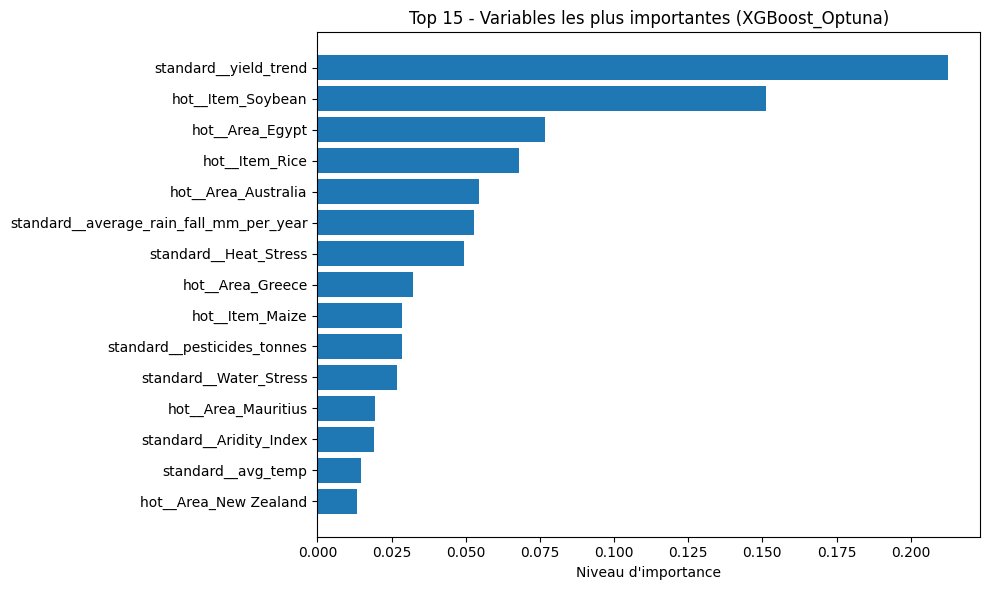

2026/03/11 12:22:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 12:22:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


   ✅ XGBoost_Optuna logué avec succès !

🏁 Tous les modèles de la série 'Champion' sont dans MLflow !


In [23]:
print("Exécution du Modèle Champion...")

# 1. Récupération de la recette gagnante d'Optuna
champion_params = study_xgb.best_params

# On rajoute les paramètres techniques qui n'étaient pas optimisés mais fixes
champion_params['random_state'] = RANDOM_STATE
champion_params['n_jobs'] = -1

# 2. Instanciation du modèle vierge avec ces hyperparamètres exacts
modele_champion = xgb.XGBRegressor(**champion_params)

# 3. Création d'un dictionnaire à modèle unique pour notre fonction MLOps
dict_champion = {
    "XGBoost_Optuna": modele_champion
}

# 4. Lancement de l'Entraînement Global et de l'Évaluation Hold-out
# Rappel : La fonction va s'occuper de tout (Fit sur TOUT le train_time, predict sur le test_time, et log)
run_and_log_experiments(
    X_train=X_train_time, 
    X_test=X_test_time, 
    y_train=y_train_time, 
    y_test=y_test_time, 
    dict_modeles=dict_champion, 
    preprocessor=preprocessor, 
    run_prefix="Champion" # Nouveau préfixe officiel !
)

### Synthèse des résultats et validation du modèle Champion

L'évaluation du modèle XGBoost optimisé sur le jeu de données temporel de test permet de valider la pertinence de la stratégie de régularisation par ablation stochastique. L'analyse des métriques de performance et des importances de variables révèle plusieurs avancées majeures pour notre architecture.

**1. Réduction de l'écart de généralisation (Overfitting)**
Les métriques finales affichent un RMSE d'entraînement de 4416 et un RMSE de test de 4836, associés à un R² de 0.96. L'écart entre l'erreur d'apprentissage et l'erreur de généralisation a été réduit à environ 9 %. Le modèle a cessé de mémoriser les données historiques et démontre une capacité robuste à inférer sur des années futures inédites. Sur le plan agronomique, une erreur moyenne de 4836 hg/ha correspond à environ 0.48 tonne par hectare, ce qui constitue une marge d'erreur tout à fait acceptable pour des prévisions de rendements agricoles à l'échelle mondiale.

**2. Restructuration de l'arbre de décision et validation des variables biophysiques**
L'analyse des *Feature Importances* confirme la réussite de la contrainte imposée au modèle :
* **Domination logique de la technologie et de la biologie :** La variable `yield_trend` demeure le principal vecteur de décision, ce qui reflète fidèlement la réalité historique de l'amélioration des rendements (intrants, génétique). L'apparition en bonne place des types de cultures (comme `Item_Soybeans`) démontre que le modèle a appris à calibrer ses prédictions selon la biologie intrinsèque de la plante, dont le poids volumique naturel varie fortement d'une espèce à l'autre.
* **Substitution de la géographie par la climatologie :** Les variables géographiques (Pays) ont disparu des critères principaux. Elles ont été remplacées par les indicateurs de contraintes environnementales, notamment les précipitations, le stress thermique (`Heat_Stress_Index`) et les températures. 
* **Phénomène de colinéarité :** Le recul relatif de l'indicateur de stress hydrique (`Water_Stress_Index`) s'explique par sa forte corrélation avec la variable des précipitations. L'algorithme des arbres de décision tend naturellement à sélectionner l'une des variables corrélées au détriment de l'autre pour diviser ses nœuds, sans que cela n'invalide l'importance physique du manque d'eau dans le processus de prédiction.

En conclusion, ces observations valident l'architecture hybride "Coupling". Le modèle "Student" exploite désormais de manière pertinente les connaissances générées par le modèle de simulation "Teacher".

## Enregistrement dans le Model Registry

In [24]:
print("Recherche du modèle Champion dans les logs MLflow...")

# 1. Recherche du run spécifique via son nom
runs_df = mlflow.search_runs(filter_string="tags.mlflow.runName = 'Champion_XGBoost_Optuna'")

if not runs_df.empty:
    # 2. Extraction du Run ID et construction de l'URI du modèle
    champion_run_id = runs_df.iloc[0].run_id
    # Le chemin correspond à l'artifact_path défini dans notre fonction run_and_log_experiments
    model_uri = f"runs:/{champion_run_id}/modele_XGBoost_Optuna"
    
    print(f"Run ID trouvé : {champion_run_id}")
    print("Inscription dans le Model Registry en cours...")
    
    # 3. Enregistrement officiel du modèle
    model_name = "Student_Yield_Predictor"
    registered_model = mlflow.register_model(model_uri=model_uri, name=model_name)
    
    print(f"Succès. Le modèle est enregistré sous le nom '{model_name}'.")
    print(f"Version actuelle : {registered_model.version}")
    
    # 4. Ajout d'une description au modèle pour la documentation CI/CD
    client = MlflowClient()
    client.update_registered_model(
        name=model_name,
        description="Modèle XGBoost régularisé (Optuna). Utilise l'architecture hybride Coupling avec données FAO et indicateurs de stress."
    )
    print("Métadonnées mises à jour avec succès.")
    
else:
    print("Erreur : Le run 'Champion_XGBoost_Optuna' est introuvable. Vérifiez l'exécution précédente.")

Recherche du modèle Champion dans les logs MLflow...
Run ID trouvé : 6616ed05c1c74927a34460af10d11eb7
Inscription dans le Model Registry en cours...


2026/03/11 12:22:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/11 12:22:18 INFO mlflow.store.db.utils: Updating database tables
2026/03/11 12:22:18 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/11 12:22:18 INFO alembic.runtime.migration: Will assume non-transactional DDL.
Registered model 'Student_Yield_Predictor' already exists. Creating a new version of this model...
2026/03/11 12:22:18 WARNING mlflow.tracking._model_registry.fluent: Run with id 6616ed05c1c74927a34460af10d11eb7 has no artifacts at artifact path 'modele_XGBoost_Optuna', registering model based on models:/m-2fea2e66b63146f78d41a880304f79b5 instead


Succès. Le modèle est enregistré sous le nom 'Student_Yield_Predictor'.
Version actuelle : 3
Métadonnées mises à jour avec succès.


Created version '3' of model 'Student_Yield_Predictor'.


In [25]:
from config.paths import DOSSIER_MODELES

print("Sanctuarisation du modèle Champion en local...")

# 1. Création propre du dossier s'il n'existe pas (via pathlib)
DOSSIER_MODELES.mkdir(parents=True, exist_ok=True)

# 2. Définition du chemin final
path_save = DOSSIER_MODELES / "pipeline_champion_xgb.pkl"

# 3. Sauvegarde du modèle
joblib.dump(pipeline_final, path_save)

print(f"✅ Modèle sauvegardé avec succès sous : {path_save}")

Sanctuarisation du modèle Champion en local...
✅ Modèle sauvegardé avec succès sous : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\models\pipeline_champion_xgb.pkl


# Modélisation recommandations et Post-Processing Expert

## Chargement du modèle

In [19]:
from config.paths import DOSSIER_MODELES

print("Chargement de l'environnement d'inférence...")

# Chargement du modèle depuis le fichier local
path_model = DOSSIER_MODELES / "pipeline_champion_xgb.pkl"
modele_prod = joblib.load(path_model)

print("✅ Modèle chargé et prêt pour les prédictions et recommandations !")

Chargement de l'environnement d'inférence...
✅ Modèle chargé et prêt pour les prédictions et recommandations !


## Création de la fonction de prédiction simple

### Vérification de la variance temporelle des features climatiques
Avant de construire notre table de référence climatique (`RefTable`) destinée à l'inférence, une inspection visuelle des données a soulevé une anomalie potentielle concernant la distribution de la pluviométrie. Pour garantir la robustesse de notre processus de recommandation, nous procédons à un diagnostic de cardinalité (variance temporelle) afin de vérifier si les variables environnementales fluctuent réellement d'une année sur l'autre au sein d'un même pays.

In [20]:
print("Chargement du dataset pour diagnostic météo...")
path_data = DONNEES_PROCESSED / "df_fao_engineered.csv" 
df_conso = pd.read_csv(path_data)

# On groupe par pays et on compte le nombre de valeurs uniques pour chaque feature
diagnostic_meteo = df_conso.groupby('Area').agg(
    annees_totales=('Year', 'nunique'),
    valeurs_uniques_pluie=('average_rain_fall_mm_per_year', 'nunique'),
    valeurs_uniques_temp=('avg_temp', 'nunique'),
    valeurs_uniques_pesticides=('pesticides_tonnes', 'nunique')
)

# On affiche un échantillon
print("Diagnostic de variance (Échantillon) :")
display(diagnostic_meteo.head(10))

# Vérification globale : combien de pays ont une pluie totalement figée ?
pays_pluie_figee = diagnostic_meteo[diagnostic_meteo['valeurs_uniques_pluie'] == 1].shape[0]
total_pays = diagnostic_meteo.shape[0]

print(f"\nBilan : {pays_pluie_figee} pays sur {total_pays} ont une pluviométrie statique")

Chargement du dataset pour diagnostic météo...
Diagnostic de variance (Échantillon) :


,annees_totales,valeurs_uniques_pluie,valeurs_uniques_temp,valeurs_uniques_pesticides
Area,,,,
Albania,23,1,21,20
Algeria,23,1,22,23
Angola,23,1,20,7
Argentina,23,1,23,20
Armenia,21,1,20,17
Australia,23,1,23,22
Austria,23,1,21,23
Azerbaijan,21,1,22,7
Bahamas,21,1,19,6



Bilan : 98 pays sur 98 ont une pluviométrie statique


**Conclusion du diagnostic agronomique :** L'analyse révèle une caractéristique structurelle critique du dataset : pour 100 % des territoires, la pluviométrie (`average_rain_fall_mm_per_year`) est une constante absolue sur les 23 années d'historique. Il s'agit d'une normale climatologique géographique et non d'un relevé météorologique annuel dynamique.

Ce constat a deux conséquences majeures pour la mise en production :
1. **Simplification de la Table de Référence :** Pour générer le climat de base d'un pays, nous extrairons directement cette constante pour la pluie, couplée à la médiane des températures récentes.
2. **Validation de l'Architecture Hybride :** Le modèle ML n'ayant techniquement pas pu apprendre l'impact des variations interannuelles de précipitations, l'ajout de notre surcouche de post-processing expert (ajustement final selon les pratiques locales d'irrigation et de conservation en eau du sol) devient non plus une simple option, mais une nécessité absolue pour garantir la pertinence de la recommandation à l'échelle de la parcelle.

### Création de la table de référence climatique

In [21]:
# Isolement de la période la plus récente (les 5 dernières années)
annee_max = df_conso['Year'].max()
df_recent = df_conso[df_conso['Year'] >= (annee_max - 4)]
print(f"Période de référence sélectionnée : {annee_max - 4} à {annee_max}")

# Calcul du climat de référence par pays
ref_table = df_recent.groupby('Area').agg(
    average_rain_fall_mm_per_year=('average_rain_fall_mm_per_year', 'first'),
    avg_temp=('avg_temp', 'median'),
    pesticides_tonnes=('pesticides_tonnes', 'median')
).reset_index()

# Sauvegarde de la table pour l'API
path_ref_table = DOSSIER_MODELES / "reference_climat.csv"
ref_table.to_csv(path_ref_table, index=False)

print(f"✅ Table de référence sauvegardée avec succès sous : {path_ref_table}")
print("\nAperçu des références pour les premiers pays :")
display(ref_table.head())

Période de référence sélectionnée : 2009 à 2013
✅ Table de référence sauvegardée avec succès sous : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\models\reference_climat.csv

Aperçu des références pour les premiers pays :


,Area,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes
0,Albania,1485.0,16.700,1132.50
1,Algeria,89.0,17.780,13861.76
2,Angola,1010.0,24.330,40.00
3,Argentina,591.0,17.755,105915.04
4,Armenia,562.0,10.200,278.72


### Création de la Table de Référence des Tendances (yield_trend)
La variable `yield_trend` modélise l'évolution technologique. Puisque notre simulation porte sur l'année 2014, nous assumons que le capital technologique d'un pays pour une culture donnée reste sensiblement identique à celui de l'année précédente. Nous extrayons donc la dernière valeur de tendance connue (2013) pour chaque couple Pays/Culture.

In [22]:
print("Génération de la Table des Tendances (TrendTable)...")

# On trie par année, puis on groupe par Pays et Culture, et on garde la dernière valeur (2013)
trend_table = df_conso.sort_values('Year').groupby(['Area', 'Item'])['yield_trend'].last().reset_index()

# Sauvegarde pour l'API
path_trend_table = DOSSIER_MODELES / "trend_reference.csv"
trend_table.to_csv(path_trend_table, index=False)

print(f"✅ Table des tendances sauvegardée avec succès sous : {path_trend_table}")
display(trend_table.head(4))

Génération de la Table des Tendances (TrendTable)...
✅ Table des tendances sauvegardée avec succès sous : C:\Users\Fab\Documents\P12_systeme_reco_agriculture\models\trend_reference.csv


,Area,Item,yield_trend
0,Albania,Maize,63324.104258
1,Albania,Soybean,19155.837703
2,Albania,Wheat,40686.145325
3,Algeria,Maize,43297.870511


### Moteur Biophysique : Réactivation des Indicateurs de Stress
Dans le cadre de notre architecture hybride "Coupling", le modèle XGBoost (le "Student") a besoin des indicateurs de stress générés par notre modèle biophysique (le "Teacher").
Nous réintégrons ici la fonction experte conçue lors de la phase de Feature Engineering. Elle calculera dynamiquement le stress hydrique et thermique de la parcelle ciblée en croisant les exigences physiologiques de la culture choisie avec la normale climatologique du pays.

In [23]:
# 1. PARAMÈTRES AGRONOMIQUES FAO
CROP_PARAMS = {
    'Wheat':   {'rain_opt': 550,  'temp_opt_min': 15, 'temp_opt_max': 25, 'temp_crit': 30},
    'Maize':   {'rain_opt': 650,  'temp_opt_min': 20, 'temp_opt_max': 30, 'temp_crit': 35},
    'Rice':    {'rain_opt': 1000, 'temp_opt_min': 22, 'temp_opt_max': 32, 'temp_crit': 36},
    'Soybean': {'rain_opt': 500,  'temp_opt_min': 20, 'temp_opt_max': 30, 'temp_crit': 35}
}

# 2. FONCTION DE CALCUL DES STRESS
def calculate_agronomic_stress(row):
    """Calcule le Water Stress et Heat Stress pour une ligne donnée."""
    crop = row.get('Item')
    rain = row.get('average_rain_fall_mm_per_year')
    temp = row.get('avg_temp')

    if pd.isna(rain) or pd.isna(temp) or crop not in CROP_PARAMS:
        return pd.Series([0.0, 0.0], index=['Water_Stress', 'Heat_Stress'])

    params = CROP_PARAMS[crop]

    # Water Stress
    delta_rain = rain - params['rain_opt']
    if delta_rain < 0:
        w_stress = abs(delta_rain) / params['rain_opt']
    else:
        w_stress = (delta_rain / params['rain_opt']) * 0.5
    w_stress = min(w_stress, 1.0)

    # Heat Stress
    h_stress = 0.0
    if temp < params['temp_opt_min']:
        h_stress = (params['temp_opt_min'] - temp) / 10
    elif temp > params['temp_opt_max']:
        h_stress = (temp - params['temp_opt_max']) / 10
        if temp > params['temp_crit']:
            h_stress *= 2.0
    h_stress = min(h_stress, 1.0)

    return pd.Series([w_stress, h_stress], index=['Water_Stress', 'Heat_Stress'])

print("✅ Moteur biophysique (Teacher) chargé en mémoire.")

✅ Moteur biophysique (Teacher) chargé en mémoire.


### Intégration des Règles Métier (Post-Processing)
Notre modèle XGBoost prédit un rendement macroscopique basé sur les tendances climatiques nationales. Pour affiner cette prédiction à l'échelle de la micro-parcelle, nous appliquons un post-processing.
Plutôt que d'utiliser des coefficients arbitraires, nous injectons ici l'intelligence extraite lors de notre phase d'EDA (Notebook 02). L'artefact `business_rules.json` contient les coefficients d'impact réels des pratiques agricoles (irrigation, fertilisation) et de la typologie des sols, convertis en tonnes par hectare.

In [24]:
# 1. Chargement de l'artefact généré dans le Notebook 02
chemin_regles = DONNEES_PROCESSED / 'business_rules.json'
with open(chemin_regles, 'r', encoding='utf-8') as f:
    business_rules = json.load(f)

print("✅ Règles métier (business_rules.json) chargées avec succès.")

# 2. La nouvelle fonction hybride
def appliquer_bonus_malus_retro(rendement_base_hg_ha, type_sol, irrigation_used, fertilizer_used):
    """
    Applique les coefficients additifs issus de la rétro-ingénierie (Notebook 02).
    """
    # Étape A : Conversion de la prédiction FAO (hg/ha) en Tonnes/ha
    rendement_final_t_ha = rendement_base_hg_ha / 10000
    # Étape B : Application des pratiques agricoles
    if fertilizer_used == 1:
        rendement_final_t_ha += business_rules.get('Fertilizer_Used', 0)
    if irrigation_used == 1:
        rendement_final_t_ha += business_rules.get('Irrigation_Used', 0)

    # Étape C : Application de l'impact du sol
    # Le JSON contient des clés du type "Soil_Type_Clay"
    cle_sol = f"Soil_Type_{type_sol}"
    if cle_sol in business_rules:
        rendement_final_t_ha += business_rules[cle_sol]
    return round(rendement_final_t_ha, 2)

✅ Règles métier (business_rules.json) chargées avec succès.


### Orchestrateur d'Inférence : Le Pipeline Hybride de Bout en Bout
Cette fonction est le cœur de notre future API. Elle orchestre la totalité du flux de prédiction :
1. **Enrichissement Macro :** Récupération de la normale climatique (`RefTable`) et de la tendance technologique (`TrendTable`).
2. **Transformation :** Formatage des saisies utilisateur en DataFrame.
3. **Feature Engineering :** Génération à la volée des indicateurs de stress et de l'Indice d'Aridité de De Martonne.
4. **Prédiction Macro (Machine Learning) :** Inférence XGBoost (gelée sur 2014).
5. **Ajustement Micro (Post-Processing) :** Application des règles expertes locales pour obtenir le rendement final en tonnes/ha.

In [25]:
# L'année de simulation pour le MVP (figée pour éviter l'extrapolation)
ANNEE_SIMULATION = 2014

def predict_single_crop(dict_user, modele, ref_table, trend_table):
    """Pipeline complet d'inférence (Data Prep -> ML -> Post-Processing)."""
    
    # --- 1. ENRICHISSEMENT MACRO ---
    pays = dict_user["Area"]
    culture = dict_user["Item"]
    
    # Récupération météo
    meteo_pays = ref_table[ref_table['Area'] == pays].iloc[0]
    
    # Récupération de la tendance technologique (2013 pour simuler 2014)
    filtre_trend = (trend_table['Area'] == pays) & (trend_table['Item'] == culture)
    tendance_tech = trend_table[filtre_trend]['yield_trend'].values[0]
    
    # Création du dictionnaire compatible avec l'entraînement
    dict_ml = {
        'Area': pays,
        'Item': culture,
        'Year': ANNEE_SIMULATION,
        'average_rain_fall_mm_per_year': meteo_pays['average_rain_fall_mm_per_year'],
        'avg_temp': meteo_pays['avg_temp'],
        'pesticides_tonnes': meteo_pays['pesticides_tonnes'],
        'yield_trend': tendance_tech # Ajout de la variable manquante !
    }
    
    # --- 2. TRANSFORMATION ---
    X_data_user = pd.DataFrame([dict_ml])
    
    # --- 3. FEATURE ENGINEERING ---
    # A. Ajout des stress agronomiques
    stress_cols = X_data_user.apply(calculate_agronomic_stress, axis=1)
    X_data_user = pd.concat([X_data_user, stress_cols], axis=1)
    
    # B. Ajout de l'Indice d'Aridité de De Martonne (manquant !)
    X_data_user['Aridity_Index'] = X_data_user['average_rain_fall_mm_per_year'] / (X_data_user['avg_temp'] + 10)
    
    # --- 4. PRÉDICTION ML (Macro) ---
    rendement_base_hg_ha = modele.predict(X_data_user)[0]
    
    # --- 5. POST-PROCESSING (Micro) ---
    rendement_final_t_ha = appliquer_bonus_malus_retro(
        rendement_base_hg_ha=rendement_base_hg_ha,
        type_sol=dict_user["Soil_Type"],
        irrigation_used=dict_user["Irrigation_Used"],
        fertilizer_used=dict_user["Fertilizer_Used"]
    )
    
    return {
        "rendement_macro_t_ha": round(rendement_base_hg_ha / 10000, 2),
        "rendement_ajuste_t_ha": rendement_final_t_ha
    }

print("✅ Pipeline d'inférence principal chargé et complet.")

✅ Pipeline d'inférence principal chargé et complet.


### Test d'Intégration : Simulation Utilisateur
Afin de valider la robustesse de notre pipeline d'inférence avant son encapsulation dans l'API FastAPI, nous simulons la requête type d'un agriculteur via l'interface Streamlit. Ce "crash-test" permet de contrôler la bonne exécution en chaîne des transformations, du modèle ML et des règles métier.

In [26]:
# Simulation de l'interface utilisateur Streamlit
mock_user_input = {
    "Area": "France",
    "Item": "Wheat",
    "Soil_Type": "Sand", 
    "Fertilizer_Used": 1,
    "Irrigation_Used": 0
}

# Appel de la fonction magique
resultat = predict_single_crop(
    dict_user=mock_user_input, 
    modele=modele_prod, 
    ref_table=ref_table,
    trend_table=trend_table # <--- AJOUT ICI
)

print(f"🌍 Simulation pour la parcelle : {mock_user_input['Area']} - {mock_user_input['Item']}")
print(f"📊 Rendement de base (Modèle ML) : {resultat['rendement_macro_t_ha']} t/ha")
print(f"🎯 Rendement final ajusté (Sol/Eau/Intrants) : {resultat['rendement_ajuste_t_ha']} t/ha")

🌍 Simulation pour la parcelle : France - Wheat
📊 Rendement de base (Modèle ML) : 7.53000020980835 t/ha
🎯 Rendement final ajusté (Sol/Eau/Intrants) : 9.029999732971191 t/ha


## Moteur de Recommandation : Recherche Exhaustive
L'objectif de cette fonction est de simuler la prédiction pour l'ensemble des cultures disponibles (Blé, Maïs, Riz, Soja) sur une parcelle donnée. Elle boucle sur notre orchestrateur d'inférence, compile les résultats, et restitue un classement ordonné par rentabilité (rendement ajusté décroissant), permettant ainsi à l'agriculteur d'optimiser son assolement.

### Fonction de recommandation

In [27]:
def recommend_best_crop(dict_user_base, modele, ref_table, trend_table):
    """
    Simule le rendement pour toutes les cultures et recommande la plus performante.
    """
    # 1. Définition de l'espace de recherche
    liste_cultures = ['Wheat', 'Maize', 'Rice', 'Soybean']
    
    # 2. Création d'une LISTE vide (et non d'un DataFrame) pour les performances
    resultats_simulation = []
    
    # 3. La boucle d'évaluation
    for culture in liste_cultures:
        # On fait une copie du dictionnaire utilisateur pour ne pas écraser l'original
        dict_simulation = dict_user_base.copy()
        
        # On injecte la culture en cours de test
        dict_simulation["Item"] = culture
        
        # On appelle notre orchestrateur
        prediction = predict_single_crop(
            dict_user=dict_simulation,
            modele=modele,
            ref_table=ref_table,
            trend_table=trend_table
        )
        
        # On stocke le résultat dans un dictionnaire temporaire
        resultats_simulation.append({
            "Culture_Recommandée": culture,
            "Rendement_Macro_t_ha": prediction["rendement_macro_t_ha"],
            "Rendement_Ajusté_t_ha": prediction["rendement_ajuste_t_ha"]
        })
        
    # 4. Conversion finale en DataFrame et Tri décroissant
    df_recommandations = pd.DataFrame(resultats_simulation)
    df_recommandations = df_recommandations.sort_values(by="Rendement_Ajusté_t_ha", ascending=False)
    
    # On reset l'index pour que le classement soit propre (1er, 2ème, etc.)
    df_recommandations = df_recommandations.reset_index(drop=True)
    df_recommandations.index += 1 # Pour que l'index commence à 1
    
    return df_recommandations

print("✅ Moteur de recommandation chargé.")

✅ Moteur de recommandation chargé.


### Test d'intégration

In [28]:
# Un agriculteur en France, sur sol sableux, irrigué et fertilisé
mock_agriculteur = {
    "Area": "France",
    "Soil_Type": "Sand", 
    "Fertilizer_Used": 1,
    "Irrigation_Used": 1
}

# Lancement du moteur de recommandation
classement_cultures = recommend_best_crop(
    dict_user_base=mock_agriculteur,
    modele=modele_prod,
    ref_table=ref_table,
    trend_table=trend_table
)

print(f"🏆 Classement des cultures pour : {mock_agriculteur['Area']} | {mock_agriculteur['Soil_Type']}")
display(classement_cultures)

🏆 Classement des cultures pour : France | Sand


,Culture_Recommandée,Rendement_Macro_t_ha,Rendement_Ajusté_t_ha
1,Maize,9.36,12.06
2,Wheat,7.53,10.23
3,Rice,5.51,8.21
4,Soybean,2.98,5.68


In [4]:
# Création d'une table de référence pays
import pandas as pd
from pathlib import Path

# === CONFIGURATION PROJET ===
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config.paths import DOSSIER_MODELES

# 1. Chargement de la table de référence (Déjà prévu pour l'inférence)
path_climat = DOSSIER_MODELES / "reference_climat.csv"
ref_table = pd.read_csv(path_climat)

# 2. Extraction dynamique de la liste des pays (Pour Pydantic)
# .unique() garantit qu'il n'y a pas de doublons, .tolist() convertit en liste Python classique
LISTE_PAYS_VALIDES = ref_table['Area'].unique().tolist()

print(f"✅ {len(LISTE_PAYS_VALIDES)} pays chargés et prêts pour la validation Pydantic.")

✅ 98 pays chargés et prêts pour la validation Pydantic.


### Axes d'amélioration et perspectives pour un MVP V2

**1. Amélioration de la granularité spatiale des données historiques**
Les données climatiques et agronomiques réelles exploitées dans ce projet présentent une résolution temporelle annuelle et une résolution spatiale à l'échelle du pays. Cette granularité est trop large pour capter la complexité du terrain. Le premier chantier d'un MVP V2 consistera à acquérir des données à une échelle beaucoup plus fine, au niveau de la région ou du comté. Cette précision permettra au modèle d'intégrer l'impact des microclimats, la qualité spécifique des sols et la disparité locale d'usage des intrants (pesticides et fertilisants, tels que mentionnés dans la consigne initiale).

**2. Remplacement des données synthétiques par des observations biologiques réelles**
L'exploration du jeu de données *Agriculture CropYield Dataset*, initialement prévu pour l'Analyse en Composantes Principales, a révélé sa nature purement synthétique. Les relations mathématiques qui le composent sont simplistes et contredisent les réalités biologiques, modélisant par exemple une corrélation positive illimitée entre la hausse des températures et l'augmentation des rendements. Pour valider pleinement la robustesse de l'approche, il sera indispensable de substituer ces données artificielles par des relevés de terrain authentiques, soumis aux véritables contraintes physiologiques des plantes.

**3. Enrichissement du modèle "Teacher" par la simulation avancée**
L'architecture hybride a prouvé son efficacité en extrayant le signal des indicateurs de stress. Pour rendre ces intrants biophysiques plus performants, les formules de calcul actuelles gagneront à être remplacées par un véritable simulateur de culture logiciel.  Cet outil permettra de générer des indicateurs intermédiaires précis en évaluant l'impact d'un événement climatique en fonction du stade de développement exact de la plante. En complément, l'intégration de séries temporelles issues de l'imagerie satellitaire offrira la possibilité de capturer l'état de santé de la biomasse en cours de saison.

**4. Transparence et Explicabilité (Explainable AI)**
Un modèle performant dans le domaine agricole doit être compris et validé par les utilisateurs finaux.  Le passage à une analyse de type SHAP (SHapley Additive exPlanations) permettra de basculer d'une importance globale des variables à une explicabilité locale. Il sera alors possible de justifier la prédiction de chaque observation en quantifiant l'impact exact d'une anomalie locale de température ou de précipitations.

**5. MLOps Avancé et Surveillance en Production**
La version suivante devra assurer la résilience du modèle dans le temps face au changement climatique. La mise en place d'outils de surveillance du Data Drift permettra de détecter les dérives des distributions météorologiques. Si le climat futur s'éloigne significativement des données d'entraînement, le système alertera automatiquement l'équipe technique pour déclencher un réentraînement du modèle, le tout intégré dans un pipeline de déploiement CI/CD complet.

### Axes d'amélioration et perspectives pour un MVP V2

**1. Refonte de la fondation de données : de l'énoncé académique à la réalité du terrain**
La consigne initiale de ce projet reposait sur l'exploitation de deux sources distinctes : 
* Un *Agriculture CropYield Dataset*, présenté comme un historique de rendements selon les cultures et les régions, destiné à une Analyse en Composantes Principales (ACP) pour l'identification des variables clés.
* Un *CropYield Prediction Dataset*, regroupant des données agronomiques et climatiques annuelles (pesticides, fertilisants, températures moyennes), destiné à valider l'analyse précédente.

L'exploration de l'Agriculture CropYield Dataset a cependant révélé qu'il s'agissait d'un jeu de données aux distributions mathématiques synthétiques, éloigné de la complexité d'un véritable historique. Bien que nous ayons pallié cette limite en construisant notre propre base consolidée, le premier chantier d'un MVP V2 consistera à sourcer des données brutes plus fidèles à la réalité.
* **Acquisition de données réelles :** Il s'agira d'intégrer des jeux de données historiques authentiques afin de confronter nos algorithmes à la véritable variance climatique et agronomique, en remplacement des distributions synthétiques.
* **Amélioration de la granularité spatiale :** L'échelle nationale utilisée dans notre projet reste trop agrégée. L'objectif sera de descendre à une échelle beaucoup plus locale pour capter plus fidèlement les variations climatiques de terrain, la diversité des sols et la disparité d'usage des intrants (pesticides et fertilisants) mentionnés dans la consigne.

**2. Enrichissement du modèle "Teacher" et nouvelles sources**
Notre architecture hybride a prouvé son efficacité en utilisant des indicateurs de stress. Pour aller plus loin, il convient d'affiner ces intrants.
* **Simulation agronomique avancée :** Remplacer nos formules actuelles par un véritable simulateur de culture logiciel pour générer des indicateurs intermédiaires plus précis, tenant compte du stade de développement de la plante au moment d'un événement climatique.
* **Intégration de nouvelles sources :** Incorporer des séries temporelles issues de l'imagerie satellitaire pour capturer l'état de santé réel de la biomasse en cours de saison.

**3. Transparence et Explicabilité (Explainable AI)**
Dans ce type de domaine d'application, un modèle performant doit être compris et validé par les utilisateurs finaux.
* **Analyse SHAP (SHapley Additive exPlanations) :**  Passer d'une simple importance globale des variables à une explicabilité locale. Cette méthode permettra d'expliquer pourquoi le modèle prédit une baisse de rendement pour une observation spécifique, en quantifiant l'impact exact d'une anomalie de température ou de précipitations.

**4. MLOps Avancé et Surveillance en Production**
Le MVP actuel a posé les bases de la traçabilité des expérimentations. La version suivante devra assurer la résilience du modèle dans le temps.
* **Détection du Data Drift :** Mettre en place des outils de surveillance continue pour détecter les dérives climatiques. Si les distributions météorologiques futures s'éloignent significativement de celles de notre jeu d'entraînement, le système devra alerter l'équipe Data pour déclencher un réentraînement.
* **Déploiement CI/CD complet :** Automatiser le pipeline de bout en bout, de l'ingestion des nouvelles données jusqu'au service des prédictions via une API REST conteneurisée.